In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.columns)
print(test_df.columns)

y = train_df["target"].astype(int)


Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')
Index(['id', 'keyword', 'location', 'text'], dtype='object')


In [ ]:
def make_text_feature(df):
    text = df["text"].fillna("").astype(str)
    keyword = df["keyword"].fillna("").astype(str)
    location = df["location"].fillna("").astype(str)

    combined = keyword + " [KEYWORD] " + location + " [LOCATION] " + text

    combined = combined.str.lower()
    combined = combined.str.replace(r"http\S+|www\.\S+", " URL ", regex=True)
    combined = combined.str.replace(r"@\w+", " USER ", regex=True)
    combined = combined.str.replace(r"#(\w+)", r"\1", regex=True)
    combined = combined.str.replace(r"\s+", " ", regex=True).str.strip()

    return combined

X_text = make_text_feature(train_df)
X_test_text = make_text_feature(test_df)

print(X_text.head())


0    [keyword] [location] our deeds are the reason ...
1    [keyword] [location] forest fire near la ronge...
2    [keyword] [location] all residents asked to 's...
3    [keyword] [location] 13,000 people receive wil...
4    [keyword] [location] just got sent this photo ...
dtype: object


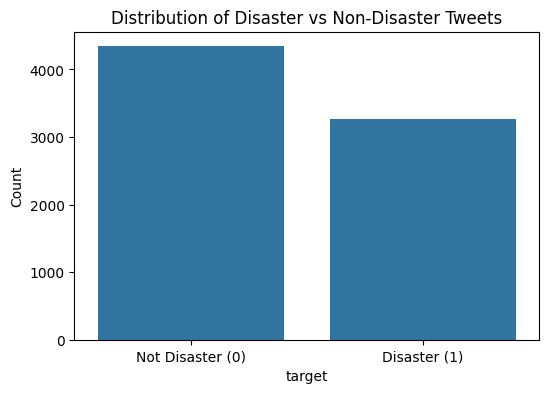

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=train_df)
plt.title("Distribution of Disaster vs Non-Disaster Tweets")
plt.xticks([0,1], ["Not Disaster (0)", "Disaster (1)"])
plt.ylabel("Count")
plt.show()

print(train_df["target"].value_counts(normalize=True))


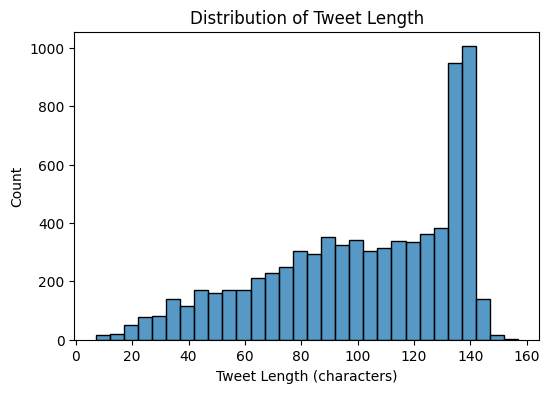

In [ ]:
train_df["tweet_length"] = train_df["text"].str.len()

plt.figure(figsize=(6,4))
sns.histplot(train_df["tweet_length"], bins=30)
plt.title("Distribution of Tweet Length")
plt.xlabel("Tweet Length (characters)")
plt.ylabel("Count")
plt.show()


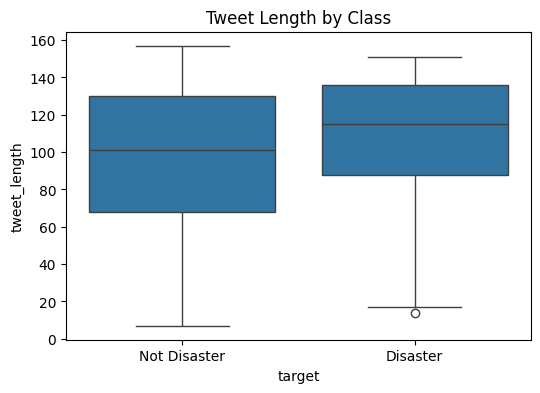

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="target", y="tweet_length", data=train_df)
plt.xticks([0,1], ["Not Disaster", "Disaster"])
plt.title("Tweet Length by Class")
plt.show()


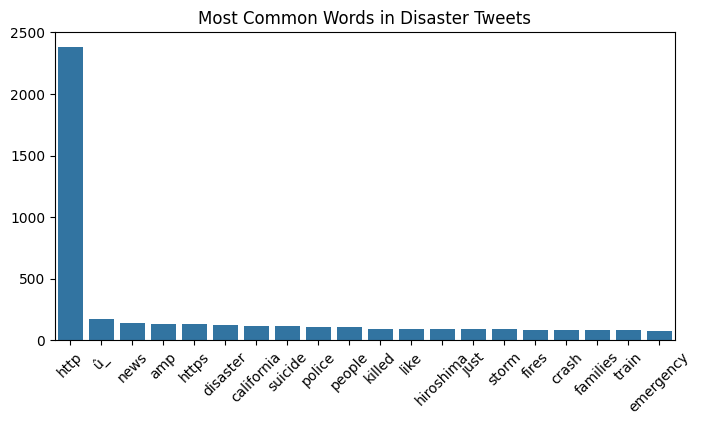

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

disaster_text = train_df[train_df["target"] == 1]["text"]

vectorizer = CountVectorizer(stop_words="english", max_features=20)
X_counts = vectorizer.fit_transform(disaster_text)

word_counts = X_counts.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

word_freq = sorted(zip(words, word_counts), key=lambda x: x[1], reverse=True)

words, counts = zip(*word_freq)

plt.figure(figsize=(8,4))
sns.barplot(x=list(words), y=list(counts))
plt.xticks(rotation=45)
plt.title("Most Common Words in Disaster Tweets")
plt.show()


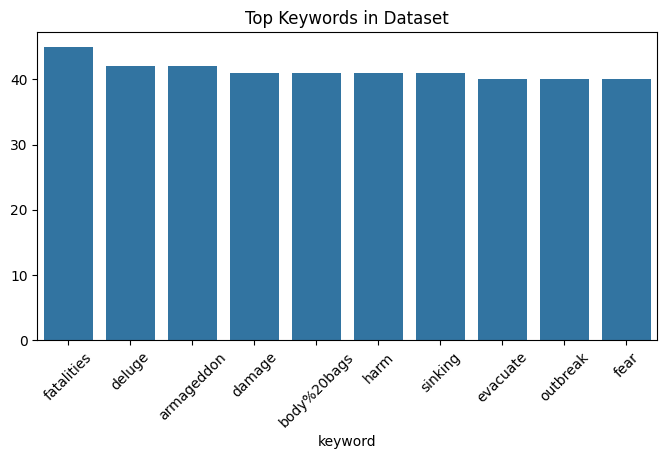

In [ ]:
top_keywords = train_df["keyword"].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top_keywords.index, y=top_keywords.values)
plt.xticks(rotation=45)
plt.title("Top Keywords in Dataset")
plt.show()


In [ ]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
word_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=60000
)

Xw_train = word_vectorizer.fit_transform(X_train_text)
Xw_val = word_vectorizer.transform(X_val_text)

word_lr = LogisticRegression(C=4.0, solver="liblinear", max_iter=2000)
word_lr.fit(Xw_train, y_train)

word_probs = word_lr.predict_proba(Xw_val)[:, 1]


In [ ]:
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True,
    max_features=50000
)

Xc_train = char_vectorizer.fit_transform(X_train_text)
Xc_val = char_vectorizer.transform(X_val_text)

char_lr = LogisticRegression(C=4.0, solver="liblinear", max_iter=2000)
char_lr.fit(Xc_train, y_train)

char_probs = char_lr.predict_proba(Xc_val)[:, 1]


In [ ]:
ensemble_probs = (word_probs + char_probs) / 2

best_f1 = 0
best_t = 0.5

for t in np.linspace(0.3, 0.7, 81):
    preds = (ensemble_probs >= t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best validation F1:", best_f1)
print("Best threshold:", best_t)


Best validation F1: 0.7905511811023622
Best threshold: 0.47


In [ ]:
# Refit vectorizers on full data
Xw_full = word_vectorizer.fit_transform(X_text)
Xw_test = word_vectorizer.transform(X_test_text)

Xc_full = char_vectorizer.fit_transform(X_text)
Xc_test = char_vectorizer.transform(X_test_text)

# Refit models
word_lr.fit(Xw_full, y)
char_lr.fit(Xc_full, y)

# Predict test probabilities
test_word_probs = word_lr.predict_proba(Xw_test)[:, 1]
test_char_probs = char_lr.predict_proba(Xc_test)[:, 1]

# Ensemble
test_probs = (test_word_probs + test_char_probs) / 2
test_preds = (test_probs >= best_t).astype(int)

# Submission file
submission = pd.DataFrame({
    "id": test_df["id"],
    "target": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
